<a href="https://colab.research.google.com/github/Dwayne-tech/DML/blob/main/Chicago_Divvy_biketrip_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# Load data
bike_data = pd.read_csv("/content/Divvy_Stations_2017_Q1Q2.csv")

# Print the columns:
print(bike_data.columns)

#
start_time_column = 'starttime'

bike_data


Index(['id', 'name', 'city', 'latitude', 'longitude', 'dpcapacity',
       'online_date'],
      dtype='object')


,id,name,city,latitude,longitude,dpcapacity,online_date
0,456,2112 W Peterson Ave,Chicago,41.991178,-87.683593,15,2/10/2015 14:04:42
1,101,63rd St Beach,Chicago,41.781016,-87.576120,23,7/16/2013 01:27:50
2,109,900 W Harrison St,Chicago,41.874675,-87.650019,19,7/18/2013 16:45:02
3,21,Aberdeen St & Jackson Blvd,Chicago,41.877726,-87.654787,15,6/22/2013 19:07:12
4,80,Aberdeen St & Madison (Monroe) St,Chicago,41.881567,-87.655056,19,6/26/2013 19:00:18
...,...,...,...,...,...,...,...
577,610,Marion St & South Blvd,Oak Park,41.886810,-87.802870,19,6/23/2016 12:24:30
578,616,Oak Park Ave & Harrison St,Oak Park,41.872987,-87.793945,19,6/23/2016 12:27:31
579,611,Oak Park Ave & South Blvd,Oak Park,41.886923,-87.793899,19,6/23/2016 12:25:00
580,612,Ridgeland Ave & Lake St,Oak Park,41.888085,-87.785236,15,6/23/2016 12:25:30


##Pre-Processing

In [56]:
#Pre-processing
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           582 non-null    int64  
 1   name         582 non-null    object 
 2   city         582 non-null    object 
 3   latitude     582 non-null    float64
 4   longitude    582 non-null    float64
 5   dpcapacity   582 non-null    int64  
 6   online_date  582 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 32.0+ KB


In [57]:
bike_data.describe()

,id,latitude,longitude,dpcapacity
count,582.000000,582.000000,582.000000,582.000000
mean,315.726804,41.887219,-87.658220,17.176976
std,180.130110,0.066976,0.043451,6.103633
min,2.000000,41.736646,-87.802870,0.000000
25%,162.250000,41.850255,-87.679409,15.000000
50%,313.500000,41.886925,-87.653947,15.000000
75%,471.750000,41.931136,-87.630845,19.000000
max,623.000000,42.063999,-87.549386,51.000000


In [62]:
# Check for missing values
print(bike_data.isnull().sum())
missing_data = bike_data[bike_data.isnull().any(axis=1)]
print(missing_data.head())

id             0
name           0
city           0
latitude       0
longitude      0
dpcapacity     0
online_date    0
dtype: int64
Empty DataFrame
Columns: [id, name, city, latitude, longitude, dpcapacity, online_date]
Index: []


##Data Analysis

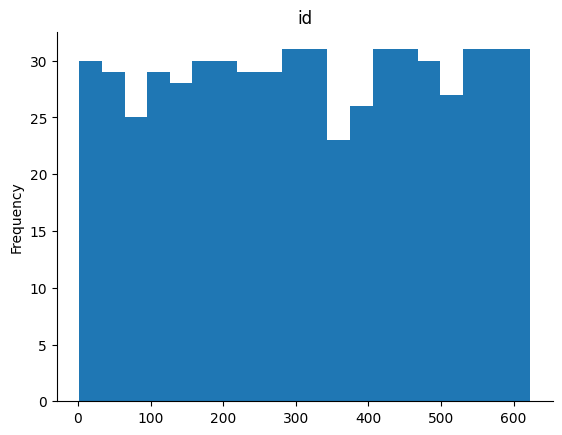

In [42]:
#Id

from matplotlib import pyplot as plt
bike_data['id'].plot(kind='hist', bins=20, title='id')
plt.gca().spines[['top', 'right',]].set_visible(False)

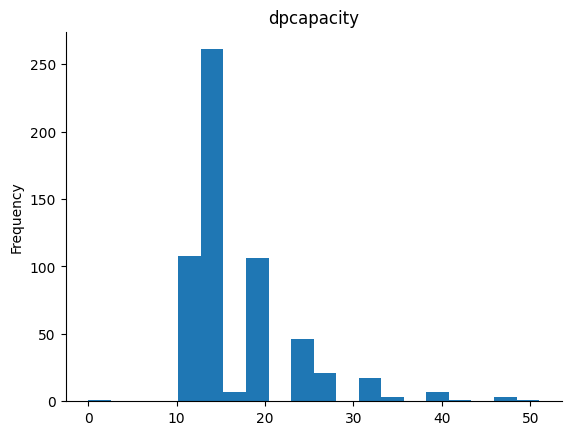

In [39]:
#Dpcapacity

from matplotlib import pyplot as plt
bike_data['dpcapacity'].plot(kind='hist', bins=20, title='dpcapacity')
plt.gca().spines[['top', 'right',]].set_visible(False)

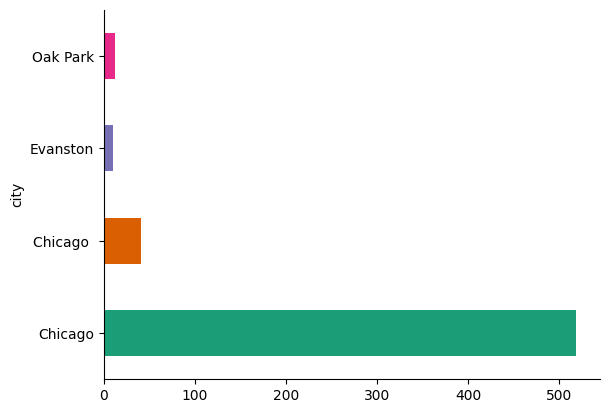

In [40]:
# City

from matplotlib import pyplot as plt
import seaborn as sns
bike_data.groupby('city').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

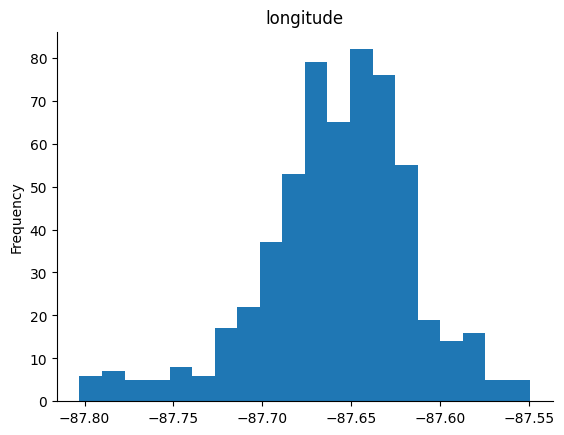

In [35]:
#Longitude

from matplotlib import pyplot as plt
bike_data['longitude'].plot(kind='hist', bins=20, title='longitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

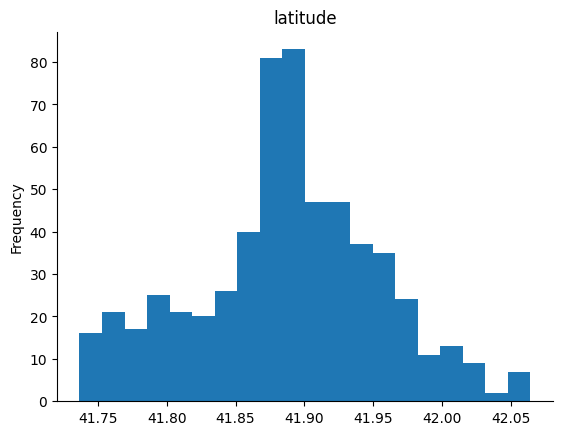

In [36]:
#Latitude

from matplotlib import pyplot as plt
bike_data['latitude'].plot(kind='hist', bins=20, title='latitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

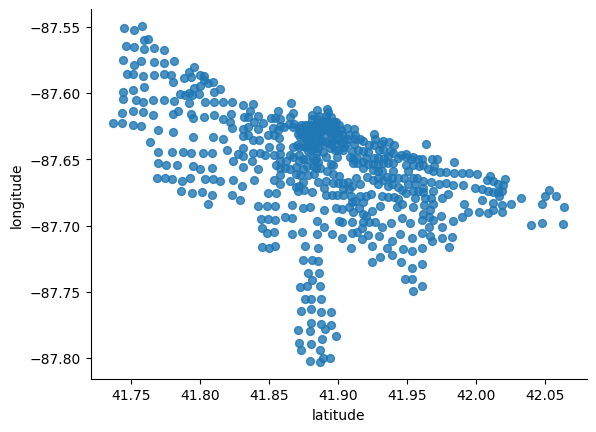

In [32]:
#latitude vs longitude

from matplotlib import pyplot as plt
bike_data.plot(kind='scatter', x='latitude', y='longitude', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

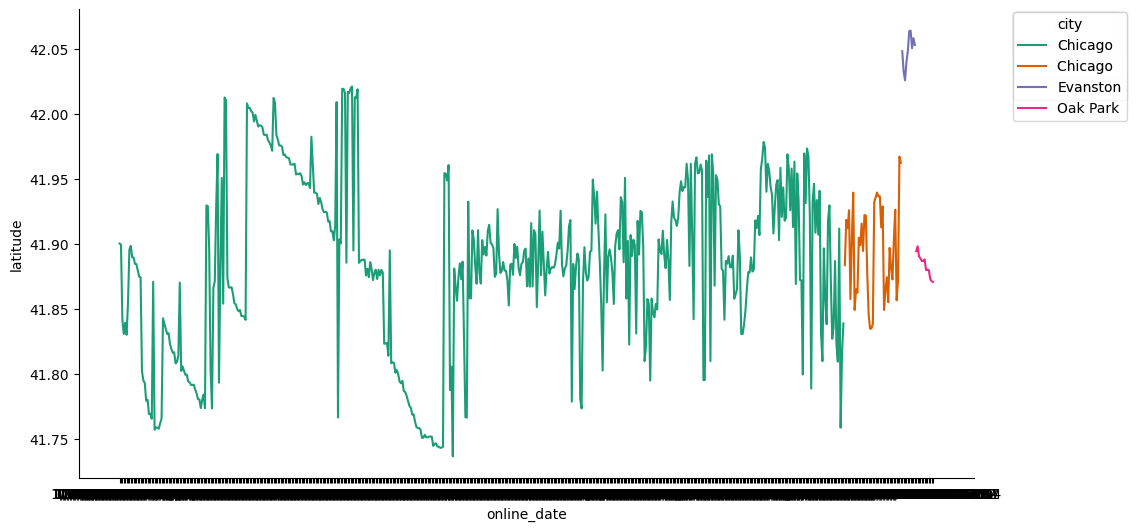

In [27]:
#Onlinedate vs latitude

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['online_date']
  ys = series['latitude']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = bike_data.sort_values('online_date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('city')):
  _plot_series(series, series_name, i)
  fig.legend(title='city', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('online_date')
_ = plt.ylabel('latitude')

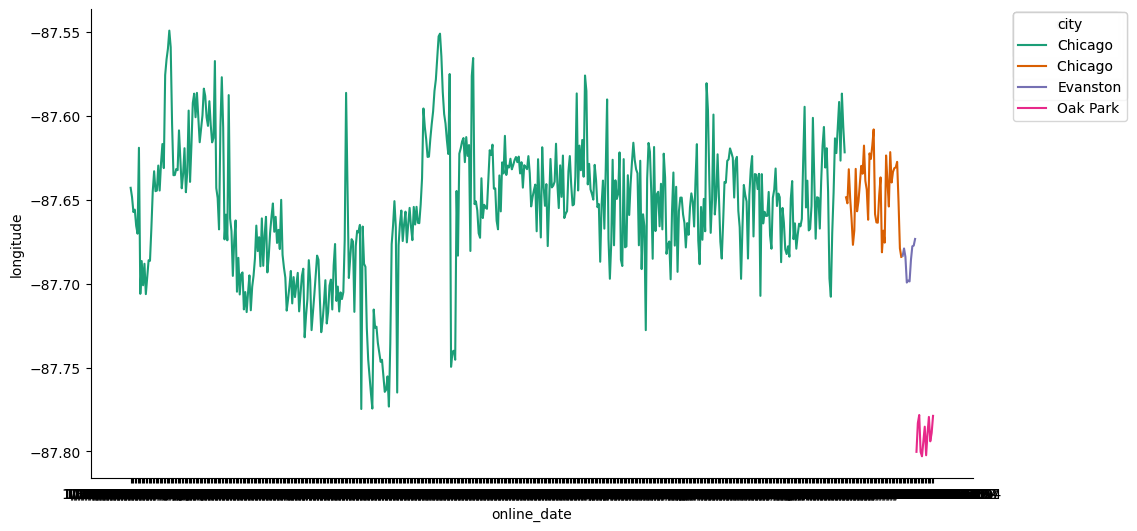

In [29]:
# Onlinedate vs longitude

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['online_date']
  ys = series['longitude']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = bike_data.sort_values('online_date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('city')):
  _plot_series(series, series_name, i)
  fig.legend(title='city', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('online_date')
_ = plt.ylabel('longitude')

<ipython-input-22-558918c1635f>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(bike_data, x='dpcapacity', y='city', inner='box', palette='Dark2')


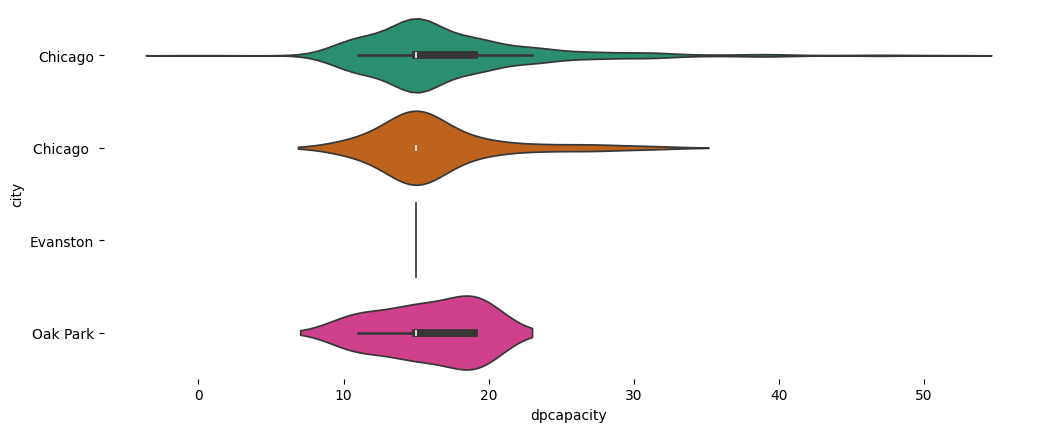

In [22]:
#  city vs dpcapacity Violin plot

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(bike_data['city'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(bike_data, x='dpcapacity', y='city', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [49]:
!pip install dash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


In [54]:
import dash
from dash import dcc, html
import plotly.express as px
import pandas as pd


# Create a Dash application with a responsive layout
app = dash.Dash(__name__)

# Convert all matplotlib/seaborn plots to Plotly equivalent

# 1. id Histogram
id_hist = px.histogram(bike_data, x='id', nbins=20, title='id Distribution')
id_hist.update_layout(showlegend=False)

# 2. dpcapacity Histogram
dpcapacity_hist = px.histogram(bike_data, x='dpcapacity', nbins=20, title='dpcapacity Distribution')
dpcapacity_hist.update_layout(showlegend=False)

# 3. City Bar Chart
city_counts = bike_data['city'].value_counts().reset_index()
city_counts.columns = ['city', 'count']
city_bar = px.bar(city_counts, x='count', y='city',
                  title='City Distribution',
                  color='city',
                  color_discrete_sequence=px.colors.qualitative.Dark2)
city_bar.update_layout(showlegend=False)

# 4. Longitude Histogram
longitude_hist = px.histogram(bike_data, x='longitude', nbins=20, title='Longitude Distribution')
longitude_hist.update_layout(showlegend=False)

# 5. Latitude Histogram
latitude_hist = px.histogram(bike_data, x='latitude', nbins=20, title='Latitude Distribution')
latitude_hist.update_layout(showlegend=False)

# 6. Latitude vs Longitude Scatter
lat_lon_scatter = px.scatter(bike_data, x='latitude', y='longitude',
                             title='Latitude vs Longitude',
                             opacity=0.8)
lat_lon_scatter.update_traces(marker=dict(size=5))

# 7. Online Date vs Latitude Line
df_sorted = bike_data.sort_values('online_date')
online_date_lat_line = px.line(df_sorted, x='online_date', y='latitude',
                               color='city',
                               title='Online Date vs Latitude by City',
                               color_discrete_sequence=px.colors.qualitative.Dark2)

# 8. Online Date vs Longitude Line
online_date_lon_line = px.line(df_sorted, x='online_date', y='longitude',
                               color='city',
                               title='Online Date vs Longitude by City',
                               color_discrete_sequence=px.colors.qualitative.Dark2)

# 9. City vs dpcapacity Violin Plot
violin_plot = px.violin(bike_data, x='dpcapacity', y='city',
                        box=True, orientation='h',
                        title='City vs dpcapacity Violin Plot',
                        color='city',
                        color_discrete_sequence=px.colors.qualitative.Dark2)
violin_plot.update_layout(showlegend=False)

# App layout
app.layout = html.Div([
    html.H1("Bike Data Dashboard"),

    html.Div([
        html.Div([dcc.Graph(figure=id_hist)], style={'width': '50%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(figure=dpcapacity_hist)], style={'width': '50%', 'display': 'inline-block'})
    ]),

    html.Div([
        html.Div([dcc.Graph(figure=city_bar)], style={'width': '50%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(figure=longitude_hist)], style={'width': '50%', 'display': 'inline-block'})
    ]),

    html.Div([
        html.Div([dcc.Graph(figure=latitude_hist)], style={'width': '50%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(figure=lat_lon_scatter)], style={'width': '50%', 'display': 'inline-block'})
    ]),

    html.Div([
        html.Div([dcc.Graph(figure=online_date_lat_line)], style={'width': '50%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(figure=online_date_lon_line)], style={'width': '50%', 'display': 'inline-block'})
    ]),

    html.Div([
        dcc.Graph(figure=violin_plot)
    ])
])

if __name__ == '__main__':
    app.run_server(debug=True)

<IPython.core.display.Javascript object>

~Creates a Dash application with a responsive layout

~Converts all matplotlib/seaborn plots to Plotly equivalents

~Organizes visualizations in a grid layout with two columns for most plots

~Maintains consistent styling and color schemes

~Includes all 9 visualizations from the original analysis

~Adds appropriate titles and legend configurations